In [25]:
import os
os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ppg_preprocess import generate_synthetic_ppg, add_noise, process_ppg_with_biosppy, process_ppg,is_ppg_signal 
from scipy.signal import butter, filtfilt
from ppg_preprocess import butter_bandpass, bandpass_filter,plot_fft,overlapping_windows,calculate_snr_around_peaks
from ppg_preprocess import *
import biosppy
import neurokit2 as nk
import scipy.stats as stats
import seaborn as sns
import matplotlib
print(matplotlib.__version__)

3.5.3


In [26]:
# Function to process a single file and return the stats
def verify_unix_times(df):
    """
    Convert unixTimes to human-readable date format to verify if they are in milliseconds.
    """
    # Ensure 'unixTimes' is numeric and drop rows with invalid values
    df['unixTimes'] = pd.to_numeric(df['unixTimes'], errors='coerce').dropna()

    # Convert from milliseconds to seconds by dividing by 1000 (if needed)
    df['human_readable_date'] = pd.to_datetime(df['unixTimes'], unit='ms')
    
    # Show the first few rows to verify the conversion
    print(df[['unixTimes', 'human_readable_date']].head())

def analyze_unix_intervals(df, threshold=2):
    """
    Analyzes the intervals between unix timestamps in the dataframe.
    
    Parameters:
    - df: The input dataframe containing a 'unixTimes' column.
    - threshold: The threshold for identifying irregular intervals (in seconds).
    
    Returns:
    - interval_stats: A dictionary containing statistics about the intervals.
    - irregular_intervals: A dataframe of rows where the time interval exceeds the threshold.
    """
    # Ensure data is sorted by unixTimes
    df = df.sort_values(by='unixTimes')
    verify_unix_times(df)
    # Calculate time intervals in seconds
    df['time_diff'] = df['unixTimes'].diff() / 1000  # Convert from milliseconds to seconds
    
    # Drop the first row (NaN created by diff)
    df = df.dropna(subset=['time_diff'])
    
    # Calculate interval statistics
    mean_interval = df['time_diff'].mean()
    min_interval = df['time_diff'].min()
    max_interval = df['time_diff'].max()
    
    # Identify irregular intervals
    irregular_intervals = df[df['time_diff'] > threshold]
    
    # Create a dictionary to store the stats
    interval_stats = {
        'mean_interval': mean_interval,
        'min_interval': min_interval,
        'max_interval': max_interval,
        'num_irregular_intervals': len(irregular_intervals)
    }
    
    return interval_stats, irregular_intervals

def calculate_hrv_from_heart_rate(ppg_obj):
    # Get the heart rate (in bpm)
    heart_rate = ppg_obj['heart_rate']
    
    # Convert heart rate to RR intervals (in seconds)
    rr_intervals = 60 / heart_rate  # RR intervals in seconds
    
    # Calculate SDNN: Standard deviation of RR intervals
    sdnn = np.std(rr_intervals) * 1000  # Convert to milliseconds
    
    # Calculate RMSSD: Square root of the mean of the squared differences of RR intervals
    rr_diff = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(rr_diff**2)) * 1000  # Convert to milliseconds
    
    return sdnn, rmssd

def analyze_ppg(df):
    SAMPLING_RATE=25
    SEGMENT_LENGTH_S=30
    STEP_SIZE_S=30
    N_FFT=512
    LOWCUT=0.2
    HIGHCUT=5
    df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
    df['ledGreen_filtered']=bandpass_filter(df['ledGreen'].dropna(), LOWCUT, HIGHCUT, SAMPLING_RATE)
    df['ledGreen_cleaned'] = nk.ppg_clean(df['ledGreen_filtered'].dropna(), sampling_rate=SAMPLING_RATE)
    print(df)
    
    segment_length = SEGMENT_LENGTH_S * SAMPLING_RATE  # Segment length in samples
    step_size = STEP_SIZE_S * SAMPLING_RATE       
    segments = overlapping_windows(df['ledGreen_cleaned'].values, segment_length, step_size)
    
    frequencies = np.fft.fftfreq(N_FFT, 1/SAMPLING_RATE)[:N_FFT // 2]
    signal_band = (frequencies >= LOWCUT) & (frequencies <= HIGHCUT)  # PPG signal band
    noise_band = (frequencies < LOWCUT) | (frequencies > HIGHCUT)     # Noise band
    
    snrs=[]
    mean_heart_rates=[]
    SDNNs=[]
    RMSSDs=[]
    no_peak_segments = 0 
    for i, segment in enumerate(segments):
        try:
            #snr = calculate_snr(segment, SAMPLING_RATE, signal_band, noise_band, 'hann', N_FFT)
            snr = calculate_snr_around_peaks(segment, SAMPLING_RATE, signal_band, noise_band, 'hann', N_FFT)
            
            ppg_obj = biosppy.signals.ppg.ppg(segment, sampling_rate=SAMPLING_RATE, show=False)
            mean_heart_rate = np.mean(ppg_obj['heart_rate'])
            mean_heart_rates.append(mean_heart_rate)

            #peaks, info = nk.ppg_peaks(segment, sampling_rate=SAMPLING_RATE, method="elgendi", show=False)
            #rr_intervals = np.diff(np.where(peaks == 1)[0]) / SAMPLING_RATE
            #rr_intervals=rr_intervals*1000
            sdnn, rmssd = calculate_hrv_from_heart_rate(ppg_obj)
            SDNNs.append(sdnn)
            RMSSDs.append(rmssd)
            snrs.append(snr)
#             if len(rr_intervals) > 0 and np.all(rr_intervals > 0):
#                 SDNN = np.std(rr_intervals)  # SDNN: Standard deviation of RR intervals
#                 RMSSD = np.sqrt(np.mean(np.diff(rr_intervals)**2))
#                 SDNNs.append(SDNN)
#                 RMSSDs.append(RMSSD)
#                 snrs.append(snr)
#             else:
#                 no_peak_segments += 1

        except Exception as e:
            print(f"there was an error: {e}")  # Print the actual error message for debugging

    valid_RMSSDs = [rmssd for rmssd in RMSSDs if not np.isnan(rmssd)]
    valid_SDNNs = [sdnn for sdnn in SDNNs if not np.isnan(sdnn)]
    mean_amplitude_ledGreen = df['ledGreen_filtered'].abs().mean()
    std_amplitude_ledGreen = df['ledGreen_filtered'].abs().std()
    
    # Calculate mean, median, and standard deviation for SNR, HR, SDNN, RMSSD
    stats = {
        'mean_amplitude_ledGreen':mean_amplitude_ledGreen,
        'std_amplitude_ledGreen':std_amplitude_ledGreen,
        
        'SNR': {
            'mean': np.mean(snrs),
            'median': np.median(snrs),
            'std': np.std(snrs)
        },
        'Heart Rate': {
            'mean': np.mean(mean_heart_rates),
            'median': np.median(mean_heart_rates),
            'std': np.std(mean_heart_rates)
        },
        'SDNN (HRV)': {
            'mean': np.mean(valid_SDNNs),
            'median': np.median(valid_SDNNs),
            'std': np.std(valid_SDNNs)
        },
        'RMSSD (HRV)': {
            'mean': np.mean(valid_RMSSDs),
            'median': np.median(valid_RMSSDs),
            'std': np.std(valid_RMSSDs)
        },
        'no_peak_segments': no_peak_segments
    }
    
    # Scatter plot of SNR vs SDNN (HRV)
#     plt.scatter(snrs, SDNNs)
#     plt.title('SNR vs SDNN (HRV)')
#     plt.xlabel('SNR')
#     plt.ylabel('SDNN (HRV)')
#     plt.grid(True)
#     plt.show()

    # Return the computed stats for SNR, Heart Rate, SDNN, and RMSSD
    return stats, snrs, SDNNs,RMSSDs, ppg_obj['heart_rate']
    
    
# Function to detect large jumps in unixTimes and calculate frequency
def process_file(file_path, time_jump_threshold=5, interval_threshold=2):
    df = pd.read_csv(file_path)
    
    # Apply sleep/awake labels
    df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep

    # Drop rows with missing values in relevant columns
    #df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])

    # Sort by unixTimes to ensure proper order of timestamps
    df = df.sort_values(by='unixTimes')

    # 1. Calculate total duration of the file in minutes and hours
    total_duration_ms = df['unixTimes'].max() - df['unixTimes'].min()  # Total duration in milliseconds
    total_duration_minutes = total_duration_ms / (1000 * 60)  # Convert to minutes
    total_duration_hours = total_duration_ms / (1000 * 60 * 60)  # Convert to hours

    # 1. Detect large jumps in unixTimes
    df['time_diff'] = df['unixTimes'].diff() / 1000  # Time difference in seconds
    big_jumps = df[df['time_diff'] > time_jump_threshold]  # Identify big jumps
    num_big_jumps = len(big_jumps)  # Count the number of big jumps

    # 2. Analyze unix time intervals
    interval_stats, irregular_intervals = analyze_unix_intervals(df, threshold=interval_threshold)

    # Lists to store consecutive window sizes
    sleep_windows = []
    awake_windows = []

    # Variables to track the start of a new window
    current_label = df['sleep_label'].iloc[0]  # Start with the first label
    start_time = df['unixTimes'].iloc[0]  # Start time of the first window

    # Iterate through the rows to count consecutive windows
    for i in range(1, len(df)):
        if df['sleep_label'].iloc[i] != current_label:
            # A new window starts, calculate the duration of the previous window
            window_duration = (df['unixTimes'].iloc[i - 1] - start_time) / 1000  # Convert to seconds
            if current_label == 1:
                sleep_windows.append(window_duration)
            else:
                awake_windows.append(window_duration)

            # Update current label and start time for the new window
            current_label = df['sleep_label'].iloc[i]
            start_time = df['unixTimes'].iloc[i]

    # Handle the last window
    window_duration = (df['unixTimes'].iloc[-1] - start_time) / 1000
    if current_label == 1:
        sleep_windows.append(window_duration)
    else:
        awake_windows.append(window_duration)

    # Calculate average, min, and max window sizes
    num_sleep_window=len(sleep_windows)
    num_awake_window=len(awake_windows)
    
    avg_sleep_window = np.mean(sleep_windows) if sleep_windows else 0
    median_sleep_window = np.median(sleep_windows) if sleep_windows else 0
    min_sleep_window = min(sleep_windows) if sleep_windows else 0
    max_sleep_window = max(sleep_windows) if sleep_windows else 0
    
    avg_awake_window = np.mean(awake_windows) if awake_windows else 0
    median_awake_window = np.median(awake_windows) if awake_windows else 0
    min_awake_window = min(awake_windows) if awake_windows else 0
    max_awake_window = max(awake_windows) if awake_windows else 0

    # 3. Calculate sampling frequencies (Hz) for each sensor
    ppg_diff = df[['ledIR', 'ledRed', 'ledGreen']].notna().sum().mean() / (df['unixTimes'].max() - df['unixTimes'].min()) * 1000  # PPG freq
    gyro_diff = df[['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']].notna().sum().mean() / (df['unixTimes'].max() - df['unixTimes'].min()) * 1000  # Gyro freq
    acc_diff = df[['accelerometerX', 'accelerometerY', 'accelerometerZ']].notna().sum().mean() / (df['unixTimes'].max() - df['unixTimes'].min()) * 1000  # Acc freq
    temp_diff = df[['tempObject']].notna().sum().mean() / (df['unixTimes'].max() - df['unixTimes'].min()) * 1000  # Temp freq

    # mean heart rate
    ppg_stats, snrs, SDNNs,RMSSDs, mean_heart_rates = analyze_ppg(df)
    
    return {
        'file': os.path.basename(file_path),
        'total_duration_minutes': total_duration_minutes,
        'total_duration_hours': total_duration_hours,
        'num_sleep_window':num_sleep_window,
        'num_awake_window':num_awake_window,
        'avg_sleep_window': avg_sleep_window,
        'median_sleep_window':median_sleep_window,
        'min_sleep_window': min_sleep_window,
        'max_sleep_window': max_sleep_window,
        'avg_awake_window': avg_awake_window,
        'median_awake_window':median_awake_window,
        'min_awake_window': min_awake_window,
        'max_awake_window': max_awake_window,
        'num_big_jumps': num_big_jumps,
        'ppg_freq': ppg_diff,
        'gyro_freq': gyro_diff,
        'acc_freq': acc_diff,
        'temp_freq': temp_diff,
        'mean_interval': interval_stats['mean_interval'],
        'min_interval': interval_stats['min_interval'],
        'max_interval': interval_stats['max_interval'],
        'num_irregular_intervals': interval_stats['num_irregular_intervals'],
        'mean_amplitude_ledGreen':ppg_stats['mean_amplitude_ledGreen'],
        'std_amplitude_ledGreen':ppg_stats['std_amplitude_ledGreen'],
        'SNR(30s win) mean':ppg_stats['SNR']['mean'],
        'SNR(30s win) median':ppg_stats['SNR']['median'],
        'SNR(30s win) std':ppg_stats['SNR']['std'],
        'HR(30s win) mean':ppg_stats['Heart Rate']['mean'],
        'HR(30s win) median':ppg_stats['Heart Rate']['median'],
        'HR(30s win) std':ppg_stats['Heart Rate']['std'],
        'SDNN HRV(30s win) mean':ppg_stats['SDNN (HRV)']['mean'],
        'SDNN HRV(30s win) median':ppg_stats['SDNN (HRV)']['median'],
        'SDNN HRV(30s win) std':ppg_stats['SDNN (HRV)']['std'],
        'RMSSD HRV(30s win) mean':ppg_stats['RMSSD (HRV)']['mean'],
        'RMSSD HRV(30s win) median':ppg_stats['RMSSD (HRV)']['median'],
        'RMSSD HRV(30s win) std':ppg_stats['RMSSD (HRV)']['std'],
        'PPG (30s win) no_peak_segments':ppg_stats['no_peak_segments']
    },snrs, SDNNs,RMSSDs,mean_heart_rates


In [ ]:
# Directory containing your CSV files
folder_path = '/home/yanwar/Desktop/Sleep/data/adhd_cleaned/'
#folder_path = '/home/yanwar/Desktop/Sleep/data/test/'

# List to store results for each file
results = []
snrs_all=[]
SDNNs_all=[]
RMSSDs_all=[]
mean_heart_rates_all = []
# Iterate over all CSV files in the directory
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        result,snrs, SDNNs,RMSSDs,mean_heart_rates = process_file(file_path)
        results.append(result)
        snrs_all.extend(snrs)
        SDNNs_all.extend(SDNNs)
        RMSSDs_all.extend(RMSSDs)
        mean_heart_rates_all.extend(mean_heart_rates)


# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)

output_csv = '/home/yanwar/Desktop/Sleep/sleep_awake_window_stats_with_freq_jumps_intervals_amp_ADHD_clean.csv'

# Append to the existing CSV file if it exists, otherwise create a new one
if not os.path.exists(output_csv):
    # If the file doesn't exist, write the DataFrame with the header
    print("File created")
    results_df.to_csv(output_csv, index=False)
else:
    print("File Appended")
    # If the file exists, append without writing the header
    results_df.to_csv(output_csv, mode='a', header=False, index=False)

# If you want to plot box-and-whisker plots for all files, you can create a combined plot
plt.figure(figsize=(10, 6))
plt.boxplot(
    [results_df['avg_sleep_window'], results_df['avg_awake_window']],
    labels=['Average Sleep Window', 'Average Awake Window'],
    showmeans=True
)
plt.title('Box and Whisker Plot of Average Sleep and Awake Window Durations Across Files')
plt.ylabel('Duration (seconds)')
plt.show()

       unixTimes     human_readable_date
0  1709777592637 2024-03-07 02:13:12.637
1  1709778944453 2024-03-07 02:35:44.453
2  1709778944481 2024-03-07 02:35:44.481
3  1709778944493 2024-03-07 02:35:44.493
4  1709778944520 2024-03-07 02:35:44.520


/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


         Unnamed: 0  counter      unixTimes  accelerometerX  accelerometerY  \
0                 3    77730  1709777592637             NaN             NaN   
1                 4        5  1709778944453             NaN             NaN   
3                 6        6  1709778944493             NaN             NaN   
5                 8        7  1709778944533             NaN             NaN   
7                10        8  1709778944573             NaN             NaN   
...             ...      ...            ...             ...             ...   
1147396     1147399  1148688  1709801638771             NaN             NaN   
1147398     1147401  1148689  1709801638811             NaN             NaN   
1147400     1147403  1148690  1709801638851             NaN             NaN   
1147402     1147405  1148691  1709801638891             NaN             NaN   
1147404     1147407  1148692  1709801638931             NaN             NaN   

         accelerometerZ  capacitorsA  gyroscopeX  g

/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/_methods.py:263: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims, where=where)
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in true_divide
  subok=False)
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: Not enough beats to compute heart rate.
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction o

...

there was an error: Not enough beats to compute heart rate.
       unixTimes     human_readable_date
0  1702949422335 2023-12-19 01:30:22.335
1  1702949422360 2023-12-19 01:30:22.360
2  1702949422375 2023-12-19 01:30:22.375
3  1702949422400 2023-12-19 01:30:22.400
4  1702949422415 2023-12-19 01:30:22.415


/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


         Unnamed: 0  counter      unixTimes  accelerometerX  accelerometerY  \
0                 1       25  1702949422335             NaN             NaN   
2                 3       26  1702949422375             NaN             NaN   
4                 5       27  1702949422415             NaN             NaN   
6                 7       28  1702949422455             NaN             NaN   
8                 9       29  1702949422495             NaN             NaN   
...             ...      ...            ...             ...             ...   
1769873     1769874  1769955  1702984391786             NaN             NaN   
1769875     1769876  1769956  1702984391826             NaN             NaN   
1769877     1769878  1769957  1702984391866             NaN             NaN   
1769879     1769880  1769958  1702984391906             NaN             NaN   
1769883     1769884  1767588  1702984548232             NaN             NaN   

         accelerometerZ  capacitorsA  gyroscopeX  g

/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: No onsets detected.
there was an error: zero-size array to reduction operation maximum which has no identity
there was an error: zero-size array to reduction operation maximum which has no identity


In [5]:
results_df

,file,total_duration_minutes,total_duration_hours,num_sleep_window,num_awake_window,avg_sleep_window,median_sleep_window,min_sleep_window,max_sleep_window,avg_awake_window,...,HR(30s win) mean,HR(30s win) median,HR(30s win) std,SDNN HRV(30s win) mean,SDNN HRV(30s win) median,SDNN HRV(30s win) std,RMSSD HRV(30s win) mean,RMSSD HRV(30s win) median,RMSSD HRV(30s win) std,PPG (30s win) no_peak_segments
0,adhd-KKI_003-right-sync.csv,5.828269e+02,9.713782e+00,14,13,2.452804e+03,1351.3865,29.929,1.190999e+04,48.432308,...,86.496170,86.516969,5.996415,126.831517,126.054563,36.327357,113.436498,111.851093,35.860146,0
1,adhd-KKI_011-right-sync.csv,2.897061e+07,4.828435e+05,25,24,6.952935e+07,269.9580,0.000,1.712648e+09,85.162458,...,NaN,NaN,NaN,130.895927,132.611691,49.192107,112.010356,107.522940,57.935842,0
2,adhd-KKI_007-right-sync.csv,2.860800e+07,4.767999e+05,21,20,8.173701e+07,1139.9730,329.952,1.698647e+09,127.473500,...,NaN,NaN,NaN,159.260259,160.271687,39.711870,145.867951,140.173788,53.925415,0
3,adhd-KKI_002-left-sync.csv,1.482188e+04,2.470313e+02,37,36,2.399573e+04,389.9870,29.990,8.578449e+05,40.807083,...,89.348328,89.492611,6.435484,148.035998,146.209379,33.626279,137.899095,134.940313,30.655529,0
4,adhd-KKI_005-right-sync.csv,3.509234e+07,5.848723e+05,26,25,8.098212e+07,734.9615,29.967,1.705977e+09,200.375520,...,80.796187,80.976483,10.337962,132.677089,134.082699,40.913951,118.514462,113.084981,49.230253,0
5,adhd-KKI_011-left-sync.csv,1.304797e+07,2.174662e+05,12,11,6.523978e+07,902.3245,29.985,7.828483e+08,79.064455,...,86.584983,87.761067,10.679974,141.865975,144.215295,39.758402,118.562795,117.204020,34.870270,0
6,adhd-KKI_009-right-sync.csv,1.115135e+07,1.858558e+05,16,15,4.181481e+07,914.9790,29.966,4.375231e+08,418.071133,...,84.474272,84.925146,9.135072,128.330850,127.129255,41.179190,118.010842,113.687078,44.603798,0
7,adhd-KKI_005-left-sync.csv,3.367392e+07,5.612320e+05,26,25,7.770886e+07,734.9755,29.984,1.705951e+09,200.373280,...,NaN,NaN,NaN,134.276626,133.405499,45.436284,123.432242,112.961047,63.383148,0
8,adhd-KKI_004-left-sync.csv,5.441369e+07,9.068949e+05,31,30,1.053167e+08,809.9750,29.986,1.705353e+09,149.972967,...,NaN,NaN,NaN,123.969276,124.303252,52.975637,121.346048,115.902558,68.526791,0
9,adhd-KKI_001-left-sync.csv,4.970286e+02,8.283810e+00,23,22,1.102220e+03,389.9550,29.956,8.099971e+03,203.159273,...,84.260678,84.341015,5.942768,129.161487,126.597724,36.753125,119.945773,117.222402,29.240493,0


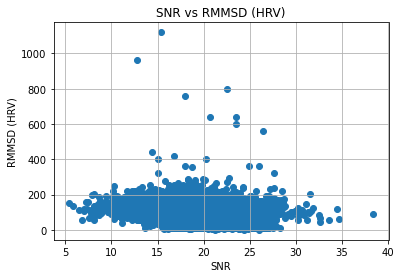

In [4]:
plt.scatter(snrs_all, RMSSDs_all)
plt.title('SNR vs RMMSD (HRV)')
plt.xlabel('SNR')
plt.ylabel('RMMSD (HRV)')
plt.grid(True)
plt.show()

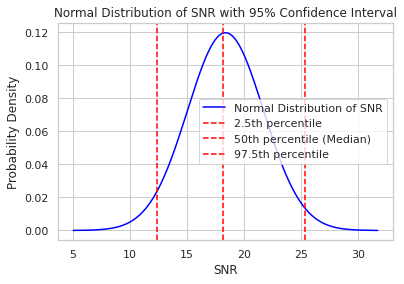

In [40]:
# Assuming mean_heart_rates_all contains the heart rate values
snrs_all = np.array(snrs_all)
snrs_all = snrs_all[~np.isnan(snrs_all)]

# Calculate mean and standard deviation
mean = np.mean(snrs_all)
std_dev = np.std(snrs_all)

# Calculate the 2.5th and 97.5th percentiles for a 95% confidence interval
percentiles = np.percentile(snrs_all, [2.5, 50, 97.5])

# Generate x values for plotting the normal distribution
x_values = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)

# Calculate y values for the normal distribution
y_values = stats.norm.pdf(x_values, mean, std_dev)

# Create the plot
plt.plot(x_values, y_values, label='Normal Distribution of SNR', color='blue')

# Add vertical lines for the 2.5th, 50th (median), and 97.5th percentiles
for percentile, label in zip(percentiles, ['2.5th percentile', '50th percentile (Median)', '97.5th percentile']):
    plt.axvline(x=percentile, color='red', linestyle='--', label=label)

# Add titles and labels
plt.title('Normal Distribution of SNR with 95% Confidence Interval')
plt.xlabel('SNR')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

49.227799227799224
[ 54.94008037  77.13737149 117.32278139]


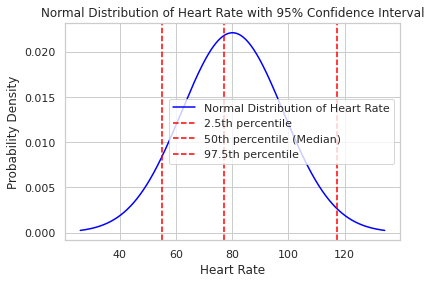

In [48]:
# Assuming mean_heart_rates_all contains the heart rate values
mean_heart_rates_all = np.array(mean_heart_rates_all)
mean_heart_rates_all = mean_heart_rates_all[~np.isnan(mean_heart_rates_all)]

# Calculate mean and standard deviation
mean = np.mean(mean_heart_rates_all)
std_dev = np.std(mean_heart_rates_all)
print(min(mean_heart_rates_all))
# Calculate the 2.5th and 97.5th percentiles for a 95% confidence interval
percentiles = np.percentile(mean_heart_rates_all, [2.5, 50, 97.5])
print(percentiles)
# Generate x values for plotting the normal distribution
x_values = np.linspace(mean - 3 * std_dev, mean + 3 * std_dev, 1000)

# Calculate y values for the normal distribution
y_values = stats.norm.pdf(x_values, mean, std_dev)

# Create the plot
plt.plot(x_values, y_values, label='Normal Distribution of Heart Rate', color='blue')

# Add vertical lines for the 2.5th, 50th (median), and 97.5th percentiles
for percentile, label in zip(percentiles, ['2.5th percentile', '50th percentile (Median)', '97.5th percentile']):
    plt.axvline(x=percentile, color='red', linestyle='--', label=label)

# Add titles and labels
plt.title('Normal Distribution of Heart Rate with 95% Confidence Interval')
plt.xlabel('Heart Rate')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

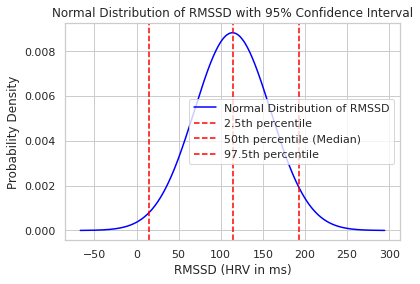

In [42]:



# Assuming mean_heart_rates_all contains the heart rate values
RMSSDs_all = np.array(RMSSDs_all)
RMSSDs_all = RMSSDs_all[~np.isnan(RMSSDs_all)]

# Calculate mean and standard deviation
mean = np.mean(RMSSDs_all)
std_dev = np.std(RMSSDs_all)

# Calculate the 2.5th and 97.5th percentiles for a 95% confidence interval
percentiles = np.percentile(RMSSDs_all, [2.5, 50, 97.5])

# Generate x values for plotting the normal distribution
x_values = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)

# Calculate y values for the normal distribution
y_values = stats.norm.pdf(x_values, mean, std_dev)

# Create the plot
plt.plot(x_values, y_values, label='Normal Distribution of RMSSD', color='blue')

# Add vertical lines for the 2.5th, 50th (median), and 97.5th percentiles
for percentile, label in zip(percentiles, ['2.5th percentile', '50th percentile (Median)', '97.5th percentile']):
    plt.axvline(x=percentile, color='red', linestyle='--', label=label)

# Add titles and labels
plt.title('Normal Distribution of RMSSD with 95% Confidence Interval')
plt.xlabel('RMSSD (HRV in ms)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [77]:
results_df['total_duration_hours']

0        3.088777
1     1531.603634
2        6.719708
3        7.686055
4        7.267258
5        5.959621
6        5.649190
7        6.706636
8        3.175602
9        6.698768
10       4.740987
11       6.176695
12       6.118165
13       7.250229
14       5.983562
15       7.459778
16       5.352848
Name: total_duration_hours, dtype: float64

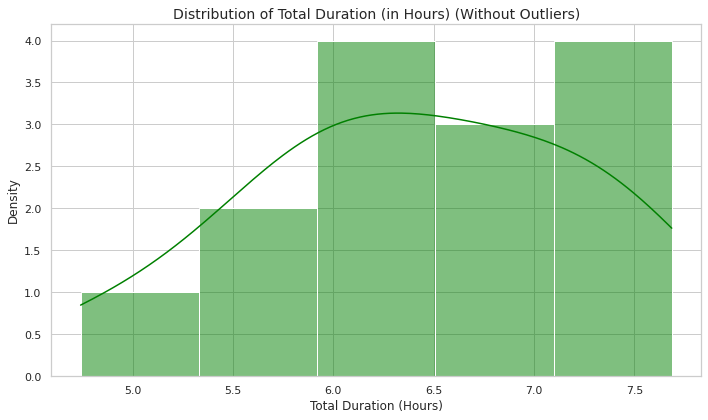

In [50]:
def remove_outliers_iqr(df, column_name):
    """
    Remove outliers from a DataFrame column using the IQR method.
    
    Parameters:
    - df: DataFrame containing the data.
    - column_name: Column from which to remove outliers.
    
    Returns:
    - DataFrame with outliers removed.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for non-outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out the outliers
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    
    return filtered_df

# Remove outliers from the 'total_duration_hours' column
filtered_df = remove_outliers_iqr(results_df, 'total_duration_hours')

# Plot after removing outliers
sns.set(style="whitegrid")

# Create a distribution plot for the total duration in hours
plt.figure(figsize=(10, 6))

# KDE plot with histogram
sns.histplot(filtered_df['total_duration_hours'], kde=True, color='green', bins=5)  # Changed color to green

# Add labels and title
plt.title('Distribution of Total Duration (in Hours) (Without Outliers)', fontsize=14)
plt.xlabel('Total Duration (Hours)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


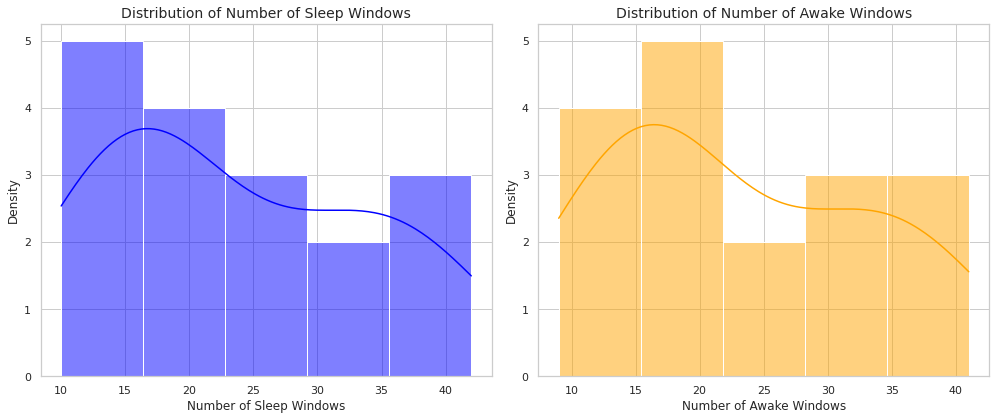

In [87]:
# Set up the plotting style
sns.set(style="whitegrid")

# Create a figure with subplots for the distribution of sleep and awake windows
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the distribution for the number of sleep windows
sns.histplot(results_df['num_sleep_window'], kde=True, ax=axes[0], color='blue', bins=5)
axes[0].set_title('Distribution of Number of Sleep Windows', fontsize=14)
axes[0].set_xlabel('Number of Sleep Windows', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)

# Plot the distribution for the number of awake windows
sns.histplot(results_df['num_awake_window'], kde=True, ax=axes[1], color='orange', bins=5)
axes[1].set_title('Distribution of Number of Awake Windows', fontsize=14)
axes[1].set_xlabel('Number of Awake Windows', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

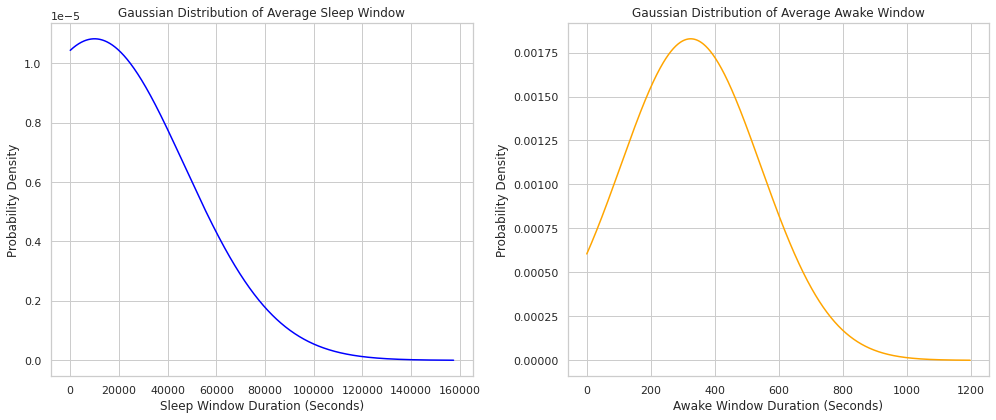

In [30]:
# Assuming you have avg_sleep_window and avg_awake_window columns
sleep_mean = np.mean(results_df['avg_sleep_window'])
sleep_std = np.std(results_df['avg_sleep_window'])

awake_mean = np.mean(results_df['avg_awake_window'])
awake_std = np.std(results_df['avg_awake_window'])

# Generate x values for the plot, ensuring no negatives
sleep_x_values = np.linspace(max(0, sleep_mean - 4 * sleep_std), sleep_mean + 4 * sleep_std, 1000)
awake_x_values = np.linspace(max(0, awake_mean - 4 * awake_std), awake_mean + 4 * awake_std, 1000)

# Calculate the Gaussian (normal) distribution for both
sleep_y_values = stats.norm.pdf(sleep_x_values, sleep_mean, sleep_std)
awake_y_values = stats.norm.pdf(awake_x_values, awake_mean, awake_std)

# Create the figure for the plots
plt.figure(figsize=(14, 6))

# Plot for average sleep
plt.subplot(1, 2, 1)
plt.plot(sleep_x_values, sleep_y_values, label='Average Sleep Window', color='blue')
plt.title('Gaussian Distribution of Average Sleep Window')
plt.xlabel('Sleep Window Duration (Seconds)')
plt.ylabel('Probability Density')
plt.grid(True)

# Plot for average awake
plt.subplot(1, 2, 2)
plt.plot(awake_x_values, awake_y_values, label='Average Awake Window', color='orange')
plt.title('Gaussian Distribution of Average Awake Window')
plt.xlabel('Awake Window Duration (Seconds)')
plt.ylabel('Probability Density')
plt.grid(True)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

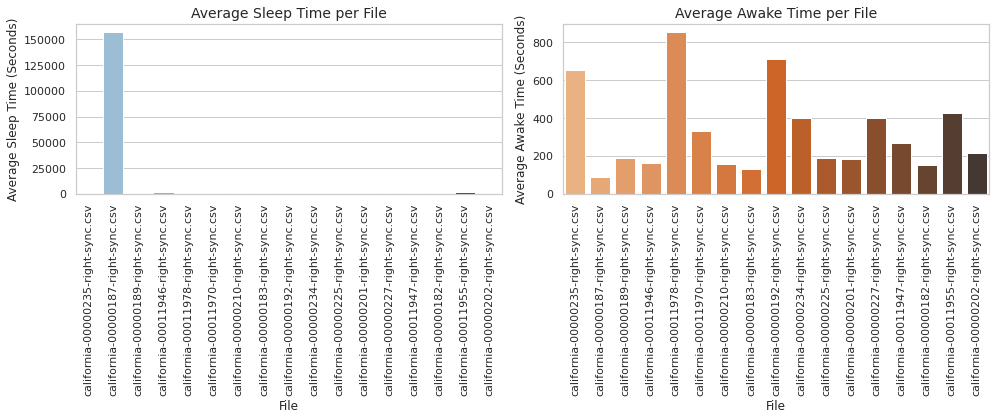

In [88]:

sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for average sleep time
sns.barplot(x='file', y='avg_sleep_window', data=results_df, ax=axes[0], palette="Blues_d")
axes[0].set_title('Average Sleep Time per File', fontsize=14)
axes[0].set_xlabel('File', fontsize=12)
axes[0].set_ylabel('Average Sleep Time (Seconds)', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability

# Plot for average awake time
sns.barplot(x='file', y='avg_awake_window', data=results_df, ax=axes[1], palette="Oranges_d")
axes[1].set_title('Average Awake Time per File', fontsize=14)
axes[1].set_xlabel('File', fontsize=12)
axes[1].set_ylabel('Average Awake Time (Seconds)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

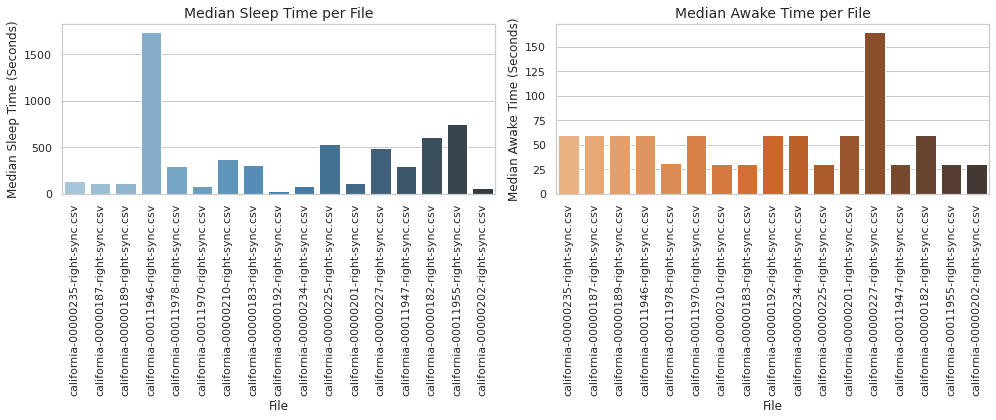

In [106]:

sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for average sleep time
sns.barplot(x='file', y='median_sleep_window', data=results_df, ax=axes[0], palette="Blues_d")
axes[0].set_title('Median Sleep Time per File', fontsize=14)
axes[0].set_xlabel('File', fontsize=12)
axes[0].set_ylabel('Median Sleep Time (Seconds)', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability

# Plot for average awake time
sns.barplot(x='file', y='median_awake_window', data=results_df, ax=axes[1], palette="Oranges_d")
axes[1].set_title('Median Awake Time per File', fontsize=14)
axes[1].set_xlabel('File', fontsize=12)
axes[1].set_ylabel('Median Awake Time (Seconds)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

In [105]:
results_df['median_awake_window']

0      59.9690
1      59.9860
2      59.9730
3      59.9570
4      31.5960
5      59.9730
6      29.9860
7      29.9930
8      59.9890
9      59.9830
10     29.9955
11     59.9685
12    164.9835
13     29.9790
14     59.9850
15     29.9800
16     29.9920
Name: median_awake_window, dtype: float64

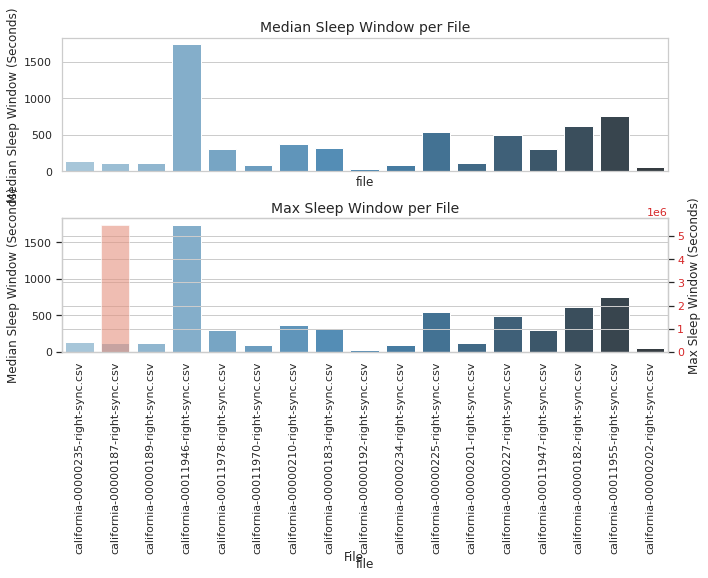

In [15]:
sns.set(style="whitegrid")

# Create a figure with 2 subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot for the median sleep window on ax1
sns.barplot(x='file', y='median_sleep_window', data=results_df, ax=ax1, palette="Blues_d")
ax1.set_ylabel('Median Sleep Window (Seconds)', fontsize=12)
ax1.set_title('Median Sleep Window per File', fontsize=14)

# Dual y-axis for max sleep window on ax2
ax2_bar = sns.barplot(x='file', y='median_sleep_window', data=results_df, ax=ax2, palette="Blues_d")
ax2.set_ylabel('Median Sleep Window (Seconds)', fontsize=12)
ax2.set_title('Max Sleep Window per File', fontsize=14)

# Create a second y-axis for the max sleep window
ax2_max = ax2.twinx()
sns.barplot(x='file', y='max_sleep_window', data=results_df, ax=ax2_max, palette="Reds_d", alpha=0.6)
ax2_max.set_ylabel('Max Sleep Window (Seconds)', fontsize=12)
ax2_max.tick_params(axis='y', labelcolor='tab:red')

# Rotate x-axis labels for better readability
ax2.tick_params(axis='x', rotation=90)

# Add a common x-label for the whole plot
fig.text(0.5, 0.04, 'File', ha='center', fontsize=12)

# Adjust layout to make sure everything fits nicely
plt.tight_layout()

# Show the plot
plt.show()

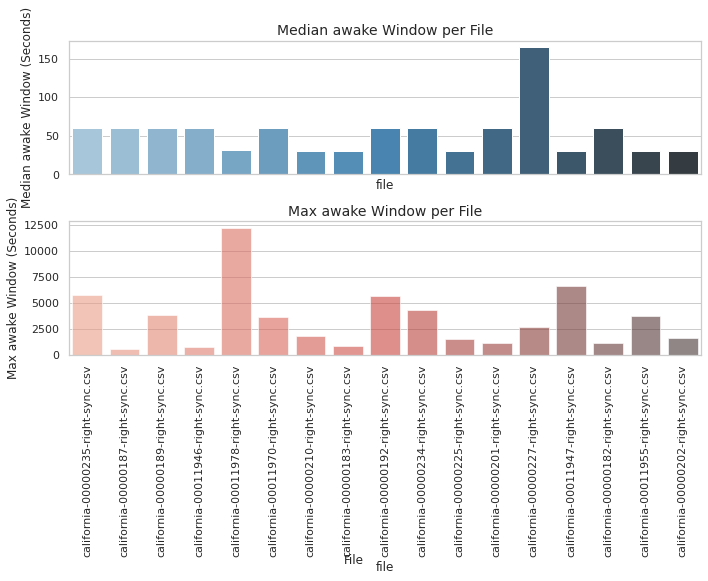

In [24]:
sns.set(style="whitegrid")

# Create a figure with 2 subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot for the median sleep window on the top axis (ax1)
sns.barplot(x='file', y='median_awake_window', data=results_df, ax=ax1, palette="Blues_d")
ax1.set_ylabel('Median awake Window (Seconds)', fontsize=12)
ax1.set_title('Median awake Window per File', fontsize=14)

# Bottom plot for the max sleep window
sns.barplot(x='file', y='max_awake_window', data=results_df, ax=ax2, palette="Reds_d", alpha=0.6)
ax2.set_ylabel('Max awake Window (Seconds)', fontsize=12)
ax2.set_title('Max awake Window per File', fontsize=14)

# Rotate x-axis labels for better readability
ax2.tick_params(axis='x', rotation=90)

# Add a common x-label for the whole plot
fig.text(0.5, 0.04, 'File', ha='center', fontsize=12)

# Adjust layout to make sure everything fits nicely
plt.tight_layout()

# Show the plot
plt.show()

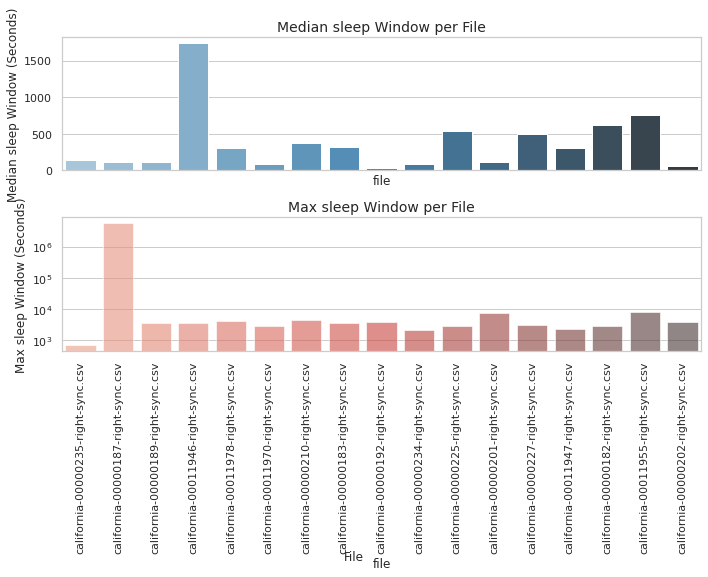

In [26]:
sns.set(style="whitegrid")

# Create a figure with 2 subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot for the median sleep window on the top axis (ax1)
sns.barplot(x='file', y='median_sleep_window', data=results_df, ax=ax1, palette="Blues_d")
ax1.set_ylabel('Median sleep Window (Seconds)', fontsize=12)
ax1.set_title('Median sleep Window per File', fontsize=14)

# Bottom plot for the max sleep window
sns.barplot(x='file', y='max_sleep_window', data=results_df, ax=ax2, palette="Reds_d", alpha=0.6)
ax2.set_ylabel('Max sleep Window (Seconds)', fontsize=12)
ax2.set_title('Max sleep Window per File', fontsize=14)
ax2.set_yscale('log')
# Rotate x-axis labels for better readability
ax2.tick_params(axis='x', rotation=90)

# Add a common x-label for the whole plot
fig.text(0.5, 0.04, 'File', ha='center', fontsize=12)

# Adjust layout to make sure everything fits nicely
plt.tight_layout()

# Show the plot
plt.show()

17.82629916427007
3.3385919834460136


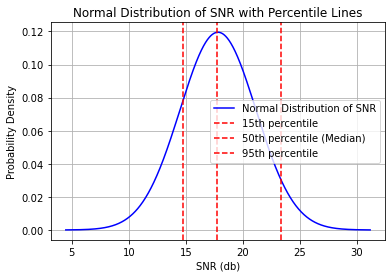

In [57]:
# Assuming RMSSDs_all contains the RMSSD values
percentiles = np.percentile(snrs_all, [15, 50, 95])
snrs_all = np.array(snrs_all)
snrs_all = snrs_all[~np.isnan(snrs_all)]
# Calculate mean and standard deviation
mean = np.mean(snrs_all)
std_dev = np.std(snrs_all)

print(mean)
print(std_dev)
# Generate x values for plotting the normal distribution
x_values = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)

y_values = stats.norm.pdf(x_values, mean, std_dev)

# Create the plot
plt.plot(x_values, y_values, label='Normal Distribution of SNR', color='blue')

# Add vertical lines for the percentiles
for percentile, label in zip(percentiles, ['15th percentile',  '50th percentile (Median)', '95th percentile']):
    plt.axvline(x=percentile, color='red', linestyle='--', label=label)

# Add titles and labels
plt.title('Normal Distribution of SNR with Percentile Lines')
plt.xlabel('SNR (db)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

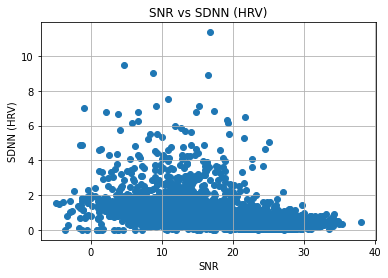

In [30]:
plt.scatter(snrs_all, SDNNs_all)
plt.title('SNR vs SDNN (HRV)')
plt.xlabel('SNR')
plt.ylabel('SDNN (HRV)')
plt.grid(True)
plt.show()

In [71]:
results_df

,file,total_duration_minutes,total_duration_hours,avg_sleep_window,min_sleep_window,max_sleep_window,avg_awake_window,min_awake_window,max_awake_window,num_big_jumps,...,HR(30s win) mean,HR(30s win) median,HR(30s win) std,SDNN HRV(30s win) mean,SDNN HRV(30s win) median,SDNN HRV(30s win) std,RMSSD HRV(30s win) mean,RMSSD HRV(30s win) median,RMSSD HRV(30s win) std,PPG (30s win) no_peak_segments
0,adhd-KKI_003-right-sync.csv,5.828269e+02,9.713782e+00,2.452804e+03,29.929,1.190999e+04,48.432308,29.959,269.964,0,...,86.496170,86.516969,5.996415,126.831517,126.054563,36.327357,113.436498,111.851093,35.860146,0
1,california-00000235-right-sync.csv,1.853267e+02,3.088777e+00,2.199699e+02,29.962,7.199440e+02,652.251923,29.963,5785.296,0,...,79.234321,79.406563,4.819319,117.748681,115.130504,34.947216,111.242534,108.626502,30.191266,0
2,california-00000187-right-sync.csv,9.189622e+04,1.531604e+03,1.574481e+05,29.955,5.492332e+06,90.860029,29.952,539.958,1,...,84.663038,85.034992,7.374417,119.824684,116.260755,44.781657,112.432863,106.163378,55.758025,0
3,adhd-KKI_011-right-sync.csv,2.897061e+07,4.828435e+05,6.952935e+07,0.000,1.712648e+09,85.162458,0.000,389.956,172,...,NaN,NaN,NaN,130.895927,132.611691,49.192107,112.010356,107.522940,57.935842,0
4,adhd-KKI_007-right-sync.csv,2.860800e+07,4.767999e+05,8.173701e+07,329.952,1.698647e+09,127.473500,29.938,719.965,19,...,NaN,NaN,NaN,159.260259,160.271687,39.711870,145.867951,140.173788,53.925415,0
5,california-00000189-right-sync.csv,4.031825e+02,6.719708e+00,3.930934e+02,29.950,3.629968e+03,187.288659,29.954,3869.991,0,...,79.203866,78.763344,6.711743,135.398848,133.415008,35.377593,130.020493,127.287202,30.504079,0
6,california-00011946-right-sync.csv,4.611633e+02,7.686055e+00,1.566433e+03,29.990,3.659991e+03,162.880187,29.964,749.993,0,...,85.661879,85.940762,7.792748,149.020265,147.608175,43.228230,135.041138,131.891389,39.550215,0
7,california-00011978-right-sync.csv,4.360355e+02,7.267258e+00,7.276751e+02,14.425,4.049951e+03,855.180000,29.959,12239.993,2,...,74.975273,74.405426,6.819730,114.224182,113.229729,38.384358,104.739879,105.004496,34.465738,0
8,adhd-KKI_002-left-sync.csv,1.482188e+04,2.470313e+02,2.399573e+04,29.990,8.578449e+05,40.807083,29.950,89.970,1,...,89.348328,89.492611,6.435484,148.035998,146.209379,33.626279,137.899095,134.940313,30.655529,0
9,california-00011970-right-sync.csv,3.575773e+02,5.959621e+00,4.479996e+02,29.970,2.909966e+03,329.971852,29.939,3689.972,0,...,76.893751,74.597675,11.577839,127.577013,130.016738,49.009417,115.843371,111.354097,58.659435,0


avg_sleep_window    3.904721e+07
avg_awake_window    2.416409e+02
dtype: float64


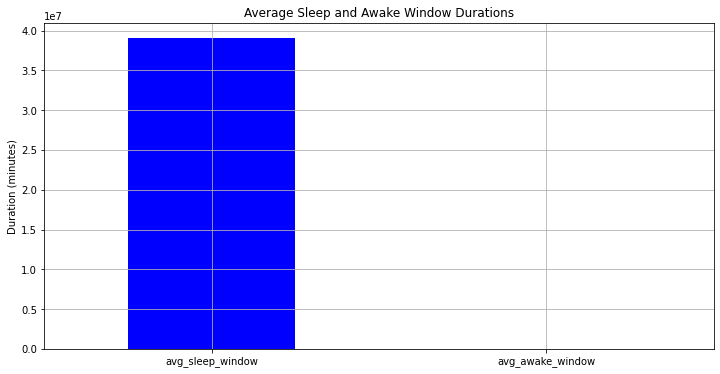

In [60]:
# Bar plot of average sleep and awake window durations
plt.figure(figsize=(12, 6))

avg_windows = results_df[['avg_sleep_window', 'avg_awake_window']].mean()
print(avg_windows)
avg_windows.plot(kind='bar', color=['blue', 'green'])

plt.title('Average Sleep and Awake Window Durations')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

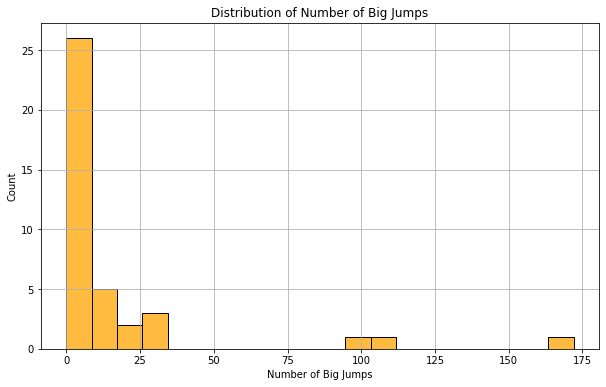

In [63]:
# Histogram of number of big jumps
plt.figure(figsize=(10, 6))

sns.histplot(results_df['num_big_jumps'], bins=20, kde=False, color='orange')
plt.title('Distribution of Number of Big Jumps')
plt.xlabel('Number of Big Jumps')
plt.ylabel('Count')
plt.grid(True)
plt.show()


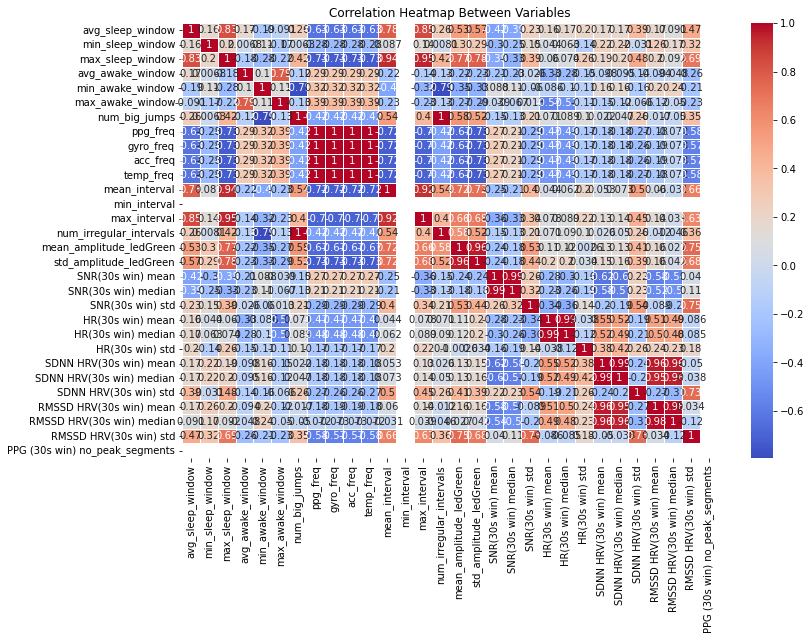

In [64]:
# Correlation heatmap
plt.figure(figsize=(12, 8))

corr_matrix = results_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap Between Variables')
plt.show()


# FEATURE CORRELATION

In [21]:
# Function to create scatter plots
def create_scatter_plot(df, feature, save_path):
    plt.figure(figsize=(8, 6))
    
    # Create scatter plot with x-axis as the feature, y-axis as index, and colors based on sleep_label
    sns.scatterplot(x=df.index, y=df[feature], hue=df['sleep_label'], palette='coolwarm', style=df['sleep_label'], markers=['o', 's'], legend='full')

    plt.title(f'Scatter Plot of {feature} with Sleep/Awake Labels')
    plt.xlabel('Index')
    plt.ylabel(f'{feature}')
    plt.legend(title='Sleep Label', loc='upper right')
    #plt.savefig(save_path)
    #plt.close()
    plt.show()
    
# Function to create distribution plots
def create_distribution_plot(df, feature, save_path):
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=feature, hue='sleep_label', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} for Sleep and Awake')
    plt.xlabel(f'{feature}')
    plt.ylabel('Density')
    #plt.savefig(save_path)
    plt.show()
    #plt.close()

# Function to create bar plot of medians
def create_median_bar_plot(df, feature_list, save_path):
    median_df = df.groupby('sleep_label')[feature_list].median().reset_index()
    median_df = pd.melt(median_df, id_vars='sleep_label', var_name='Feature', value_name='Median')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Feature', y='Median', hue='sleep_label', data=median_df, palette='coolwarm')
    plt.title(f'Median of Features for Sleep and Awake')
    plt.xlabel('Feature')
    plt.ylabel('Median Value')
    #plt.savefig(save_path)
    plt.show()
    #plt.close()


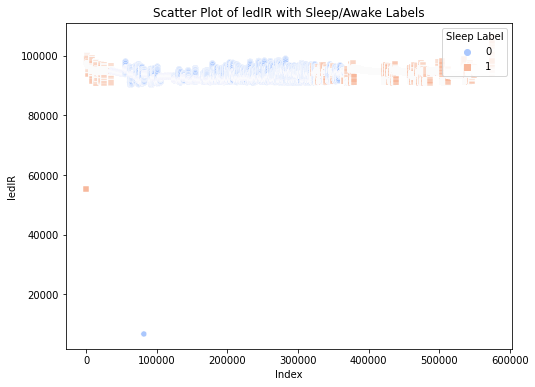

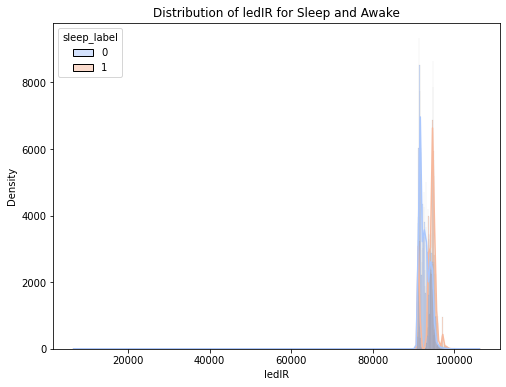

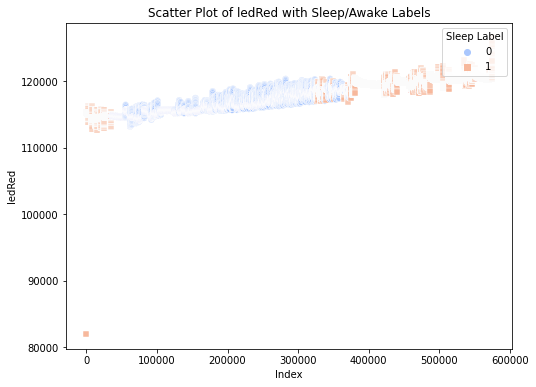

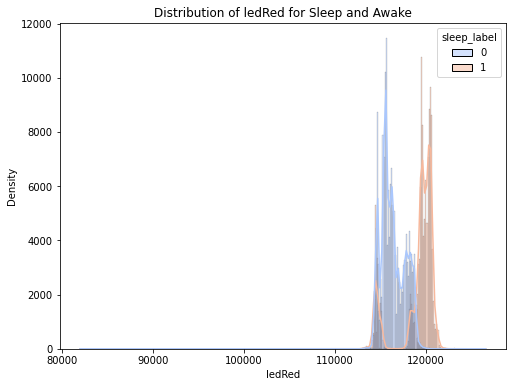

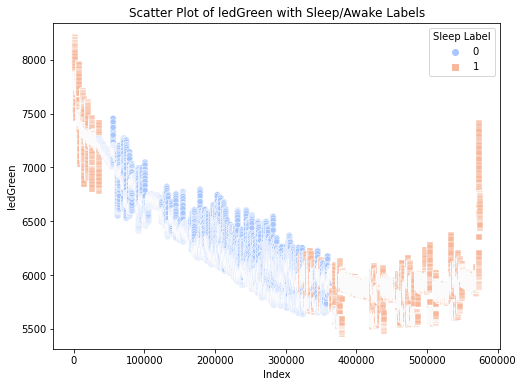

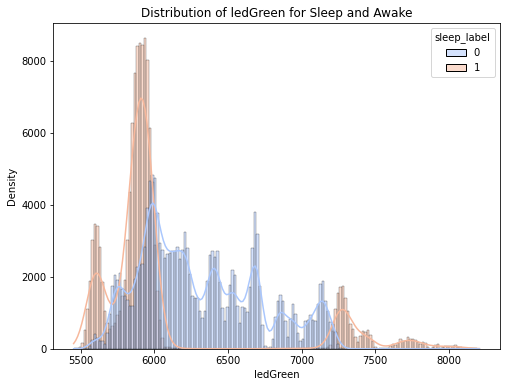

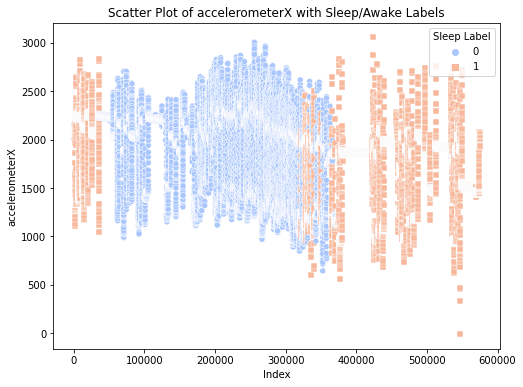

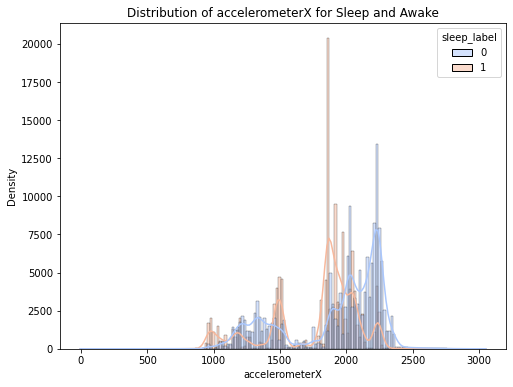

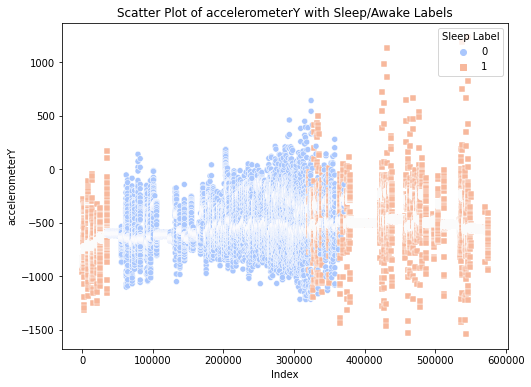

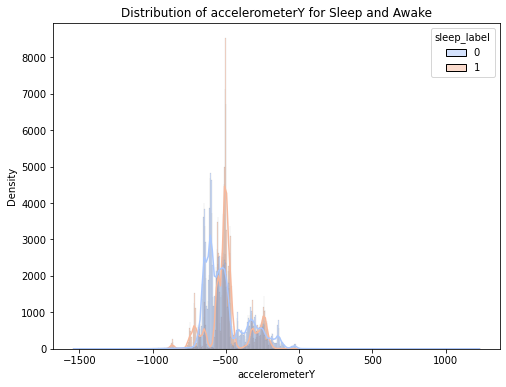

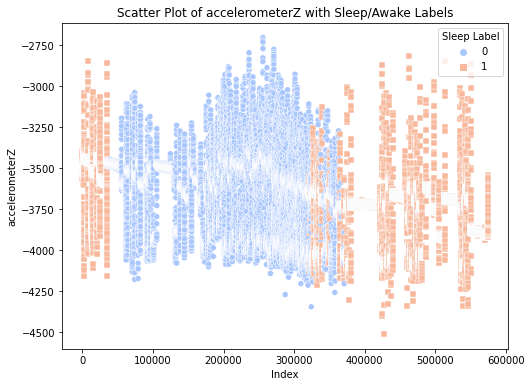

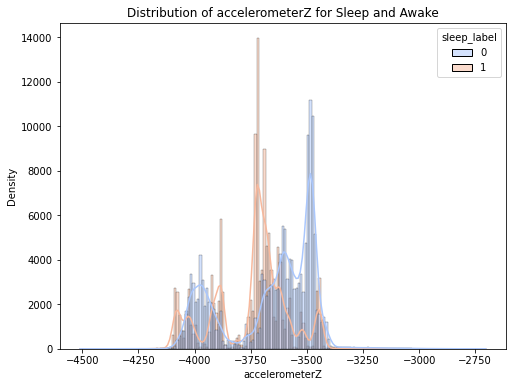

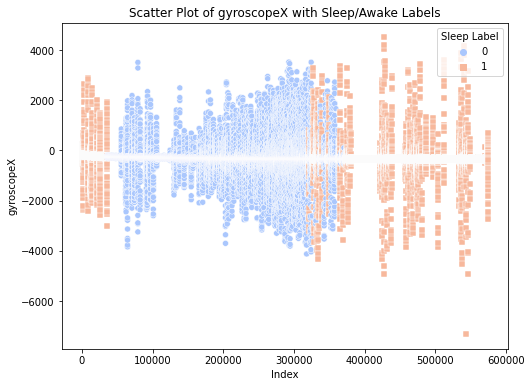

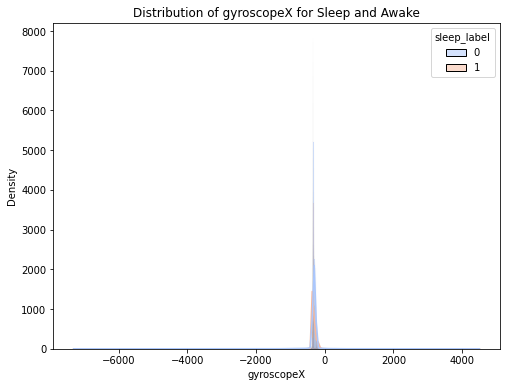

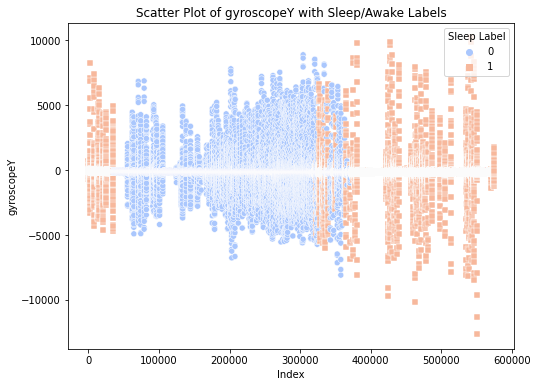

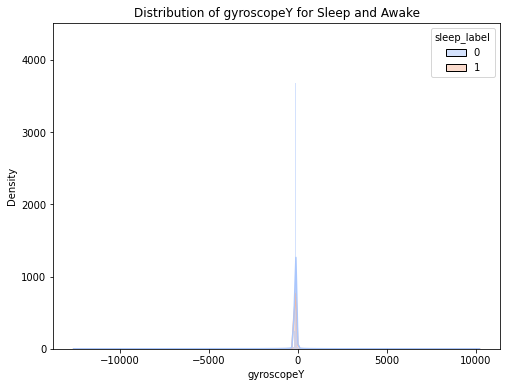

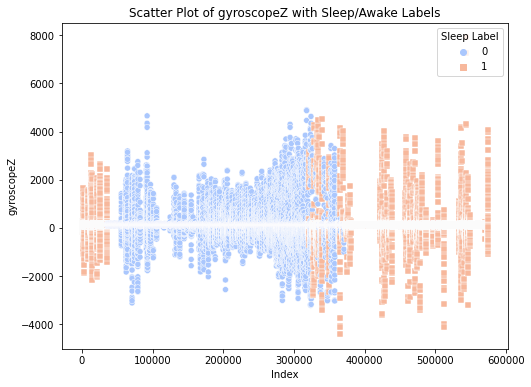

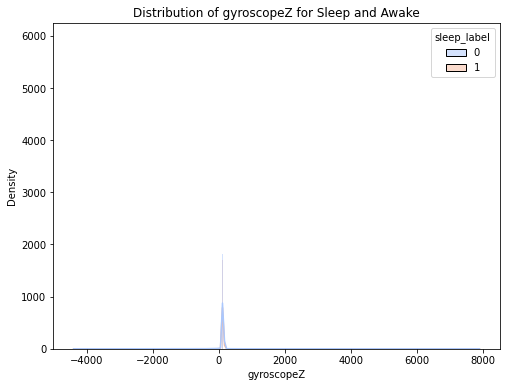

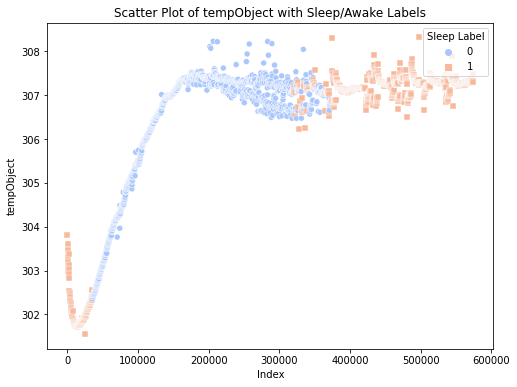

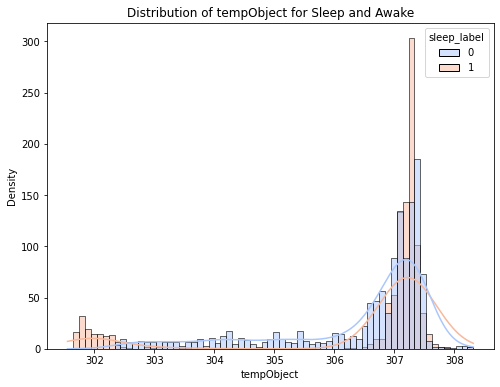

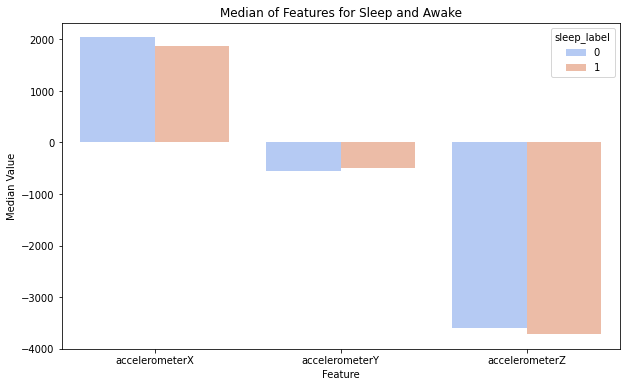

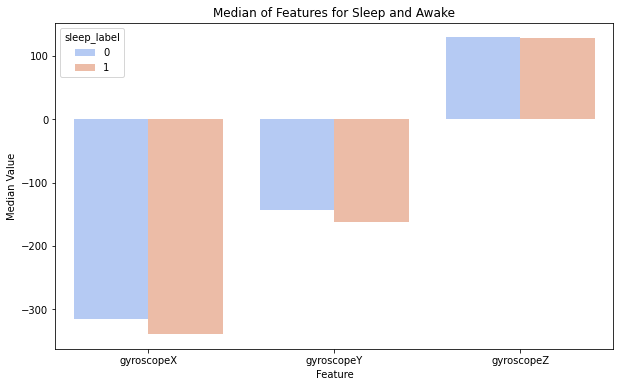

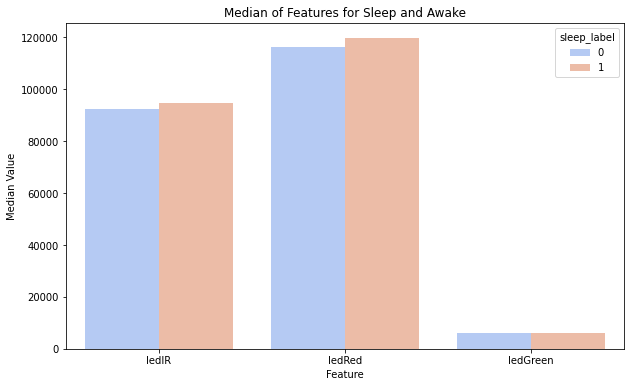

In [24]:
folder_path = '/home/yanwar/Desktop/Sleep/data/test/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        temp_df = df.dropna(subset=['tempObject', 'sleep_label'])
        
        # PPG Scatter and Distribution Plots
        for feature in ['ledIR', 'ledRed', 'ledGreen']:
            create_scatter_plot(PPG_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(PPG_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Accelerometer Scatter and Distribution Plots
        for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
            create_scatter_plot(acc_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(acc_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Gyroscope Scatter and Distribution Plots
        for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
            create_scatter_plot(gyro_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(gyro_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Temperature Scatter and Distribution Plots
        create_scatter_plot(temp_df, 'tempObject', f'plots/scatter/{filename}_scatter_tempObject.png')
        create_distribution_plot(temp_df, 'tempObject', f'plots/distribution/{filename}_dist_tempObject.png')

#         # Bar Plot of Medians for Accelerometer, Gyroscope, and PPG
        create_median_bar_plot(acc_df, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/median_bar/{filename}_acc_median_bar.png')
        create_median_bar_plot(gyro_df, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/median_bar/{filename}_gyro_median_bar.png')
        create_median_bar_plot(PPG_df, ['ledIR', 'ledRed', 'ledGreen'], f'plots/median_bar/{filename}_ppg_median_bar.png')
        
        
        
        
        break